In [57]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

In [58]:
X, y = make_circles(n_samples = 1000, random_state = 42, noise = 0.03)

In [59]:
df = pd.DataFrame(X, y)
X.shape, y.shape

((1000, 2), (1000,))

In [60]:
X_reduced = PCA(n_components = 2).fit_transform(X)

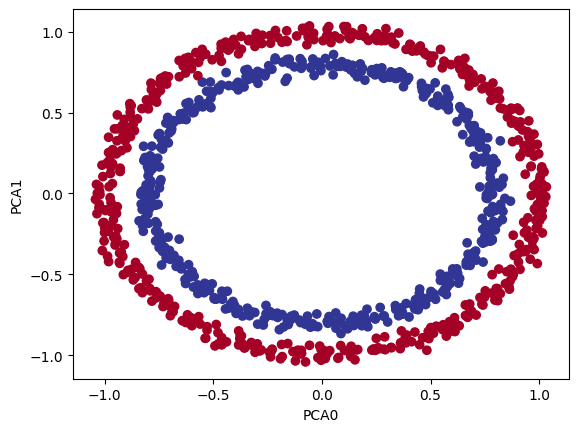

In [61]:
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y, cmap=plt.cm.RdYlBu)
plt.xlabel("PCA0")
plt.ylabel("PCA1")
plt.show()

In [62]:
## Turning ndarray(numpy array) into torch.tensor

X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

In [63]:
# Train,Test split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [65]:
X_train.shape

torch.Size([800, 2])

In [67]:
device = "mps" if torch.backends.mps.is_available() else "cpu"
device

'mps'

In [72]:
class MultiLayerClassifier(torch.nn.Module):
    def __init__(self):
        super().__init__()

        ## Linear Layer (multi)
        self.layer_1 = torch.nn.Linear(
            in_features = 2, out_features = 5,
        )

        self.layer_2 = torch.nn.Linear(
            in_features = 5, out_features = 1
        )

        ## Method 2 (sequential layer)
        # self.seq_layer = torch.nn.Sequential(
        #     torch.nn.Linear(
        #         in_features = 2, out_features = 5
        #    ),
        #     torch.nn.Linear(
        #         in_features = 5, out_features = 1
        #     )
        # )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.layer_2(self.layer_1(x))

In [73]:
model = MultiLayerClassifier().to(device)

In [75]:
model(X_train.to(device))

tensor([[0.3695],
        [0.3910],
        [0.1384],
        [0.1527],
        [0.1551],
        [0.1847],
        [0.1383],
        [0.2735],
        [0.1064],
        [0.4014],
        [0.1258],
        [0.1349],
        [0.4050],
        [0.1038],
        [0.2579],
        [0.2338],
        [0.1798],
        [0.1829],
        [0.3749],
        [0.1396],
        [0.3687],
        [0.3429],
        [0.3768],
        [0.2641],
        [0.1303],
        [0.1344],
        [0.1669],
        [0.0967],
        [0.1218],
        [0.1183],
        [0.3578],
        [0.2482],
        [0.2107],
        [0.3642],
        [0.3676],
        [0.1305],
        [0.3471],
        [0.1542],
        [0.1445],
        [0.1817],
        [0.1376],
        [0.2631],
        [0.2508],
        [0.2797],
        [0.2786],
        [0.3550],
        [0.1752],
        [0.3112],
        [0.2417],
        [0.3052],
        [0.1726],
        [0.1900],
        [0.2930],
        [0.1263],
        [0.1557],
        [0